# Install

In [1]:
!pip3 install pandas matplotlib

# Imports

In [2]:
import pandas as pd

# Load your dataset
data = pd.read_csv("bixi_stations.csv")

# Show basic info
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nFirst 5 rows:")
data.head()

Shape: (100, 1)

Columns:
Index(['Table 1'], dtype='str')

First 5 rows:


,,,,,,,,,,Table 1
STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,hour
Métro Champ-de-Mars (Viger / Sanguinet),Ville-Marie,45.51025293429710,-73.55677664279940,St-Antoine / Jean-Paul Riopelle,Ville-Marie,45.502939709023700,-73.56064036488530,1704230756167,1704231106232,21
Métro Place-d'Armes (Viger / St-Urbain),Ville-Marie,45.50631445605530,-73.55967122894070,de Maisonneuve / Aylmer (est),Ville-Marie,45.50538591756770,-73.5704317688942,1704232888826,1704233303502,22
Émile-Duployé / Sherbrooke,Le Plateau-Mont-Royal,45.52719536319050,-73.5645255446434,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.54902230455400,-73.59198164194820,1704238154678,1704239359500,23
Marmier / St-Denis,Rosemont - La Petite-Patrie,45.53102667048670,-73.59862312674520,Roy / St-André,Le Plateau-Mont-Royal,45.521564270906600,-73.57036739587780,1704232695740,1704233329014,21


In [3]:
import pandas as pd

data = pd.read_csv("bixi_stations.csv", sep="\t")

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

data.head()

Shape: (100, 1)

Columns:
Index(['Table 1'], dtype='str')


,Table 1
0,"STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,ST..."
1,"Métro Champ-de-Mars (Viger / Sanguinet),Ville-..."
2,"Métro Place-d'Armes (Viger / St-Urbain),Ville-..."
3,"Émile-Duployé / Sherbrooke,Le Plateau-Mont-Roy..."
4,"Marmier / St-Denis,Rosemont - La Petite-Patrie..."


In [4]:
import pandas as pd

# Read file safely (ignore parsing errors)
data = pd.read_csv("bixi_stations.csv", header=None, engine="python", on_bad_lines="skip")

# Now split the single column manually
data = data[0].str.split(",", expand=True)

# First row = header
data.columns = data.iloc[0]

# Remove header row
data = data[1:]

# Reset index
data = data.reset_index(drop=True)

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

data.head()

Shape: (0, 1)

Columns:
Index(['Table 1'], dtype='str', name=0)


,Table 1


In [5]:
import pandas as pd

# Skip first garbage rows (important)
data = pd.read_csv(
    "bixi_stations.csv",
    skiprows=1,          # skip "Table 1"
    engine="python"
)

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

data.head()

Shape: (99, 11)

Columns:
Index(['STARTSTATIONNAME', 'STARTSTATIONARRONDISSEMENT',
       'STARTSTATIONLATITUDE', 'STARTSTATIONLONGITUDE', 'ENDSTATIONNAME',
       'ENDSTATIONARRONDISSEMENT', 'ENDSTATIONLATITUDE', 'ENDSTATIONLONGITUDE',
       'STARTTIMEMS', 'ENDTIMEMS', 'hour'],
      dtype='str')


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,hour
0,Métro Champ-de-Mars (Viger / Sanguinet),Ville-Marie,45.510253,-73.556777,St-Antoine / Jean-Paul Riopelle,Ville-Marie,45.502940,-73.560640,1704230756167,1704231106232,21
1,Métro Place-d'Armes (Viger / St-Urbain),Ville-Marie,45.506314,-73.559671,de Maisonneuve / Aylmer (est),Ville-Marie,45.505386,-73.570432,1704232888826,1704233303502,22
2,Émile-Duployé / Sherbrooke,Le Plateau-Mont-Royal,45.527195,-73.564526,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1704238154678,1704239359500,23
3,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.531027,-73.598623,Roy / St-André,Le Plateau-Mont-Royal,45.521564,-73.570367,1704232695740,1704233329014,21
4,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.531027,-73.598623,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1704243796167,1704244484511,1


In [6]:
# Use only start station info
data_clean = data[[
    "STARTSTATIONNAME",
    "STARTSTATIONLATITUDE",
    "STARTSTATIONLONGITUDE"
]]

# Rename for simplicity
data_clean = data_clean.rename(columns={
    "STARTSTATIONNAME": "station_name",
    "STARTSTATIONLATITUDE": "latitude",
    "STARTSTATIONLONGITUDE": "longitude"
})

# Remove duplicates
data_clean = data_clean.drop_duplicates().reset_index(drop=True)

data_clean.head()

,station_name,latitude,longitude
0,Métro Champ-de-Mars (Viger / Sanguinet),45.510253,-73.556777
1,Métro Place-d'Armes (Viger / St-Urbain),45.506314,-73.559671
2,Émile-Duployé / Sherbrooke,45.527195,-73.564526
3,Marmier / St-Denis,45.531027,-73.598623
4,du Parc-Lafontaine / Rachel,45.525512,-73.574245


In [7]:
import random

# Select station
row = data_clean.iloc[0]

station_name = row["station_name"]
capacity = 20  # assumed

# Better simulation (more realistic)
demand = random.randint(5, capacity)
available_bikes = random.randint(0, capacity)

# Utilization
utilization = round((available_bikes / capacity) * 100, 2)

remaining = available_bikes - demand

print("Station:", station_name)
print("Capacity:", capacity)
print("Available Bikes:", available_bikes)
print("Demand:", demand)
print("Utilization (%):", utilization)

if remaining >= 0:
    print("✔ Enough bikes available:", remaining)
else:
    print("❌ Shortage of bikes:", -remaining)

Station: Métro Champ-de-Mars (Viger / Sanguinet)
Capacity: 20
Available Bikes: 10
Demand: 5
Utilization (%): 50.0
✔ Enough bikes available: 5


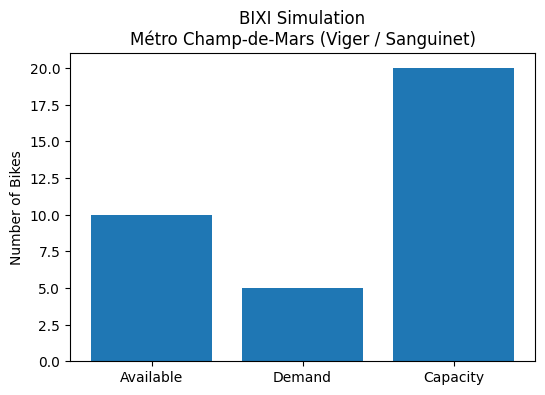

In [8]:
import matplotlib.pyplot as plt

labels = ["Available", "Demand", "Capacity"]
values = [available_bikes, demand, capacity]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title(f"BIXI Simulation\n{station_name}")
plt.ylabel("Number of Bikes")
plt.show()

In [9]:
import random

# Assume 5 stations
num_stations = 5
capacity = [20]*num_stations
bikes = [random.randint(5,20) for _ in range(num_stations)]

# KPIs
stockout = [0]*num_stations
overflow = [0]*num_stations
success_pickups = [0]*num_stations
success_returns = [0]*num_stations


def simulate_step():
    global bikes
    
    for i in range(num_stations):
        pickups = random.randint(0, 3)
        returns = random.randint(0, 3)

        # pickups
        for _ in range(pickups):
            if bikes[i] > 0:
                bikes[i] -= 1
                success_pickups[i] += 1
            else:
                stockout[i] += 1

        # returns
        for _ in range(returns):
            if bikes[i] < capacity[i]:
                bikes[i] += 1
                success_returns[i] += 1
            else:
                overflow[i] += 1

In [10]:
for _ in range(10):
    simulate_step()

In [11]:
import pandas as pd

df = pd.DataFrame({
    "Station": [f"S{i}" for i in range(num_stations)],
    "Bikes": bikes,
    "Stockout": stockout,
    "Overflow": overflow,
    "Pickups": success_pickups,
    "Returns": success_returns
})

df

,Station,Bikes,Stockout,Overflow,Pickups,Returns
0,S0,14,0,0,15,12
1,S1,13,0,0,14,18
2,S2,9,0,0,17,12
3,S3,14,0,0,9,15
4,S4,15,0,0,14,21


<Axes: xlabel='Station'>

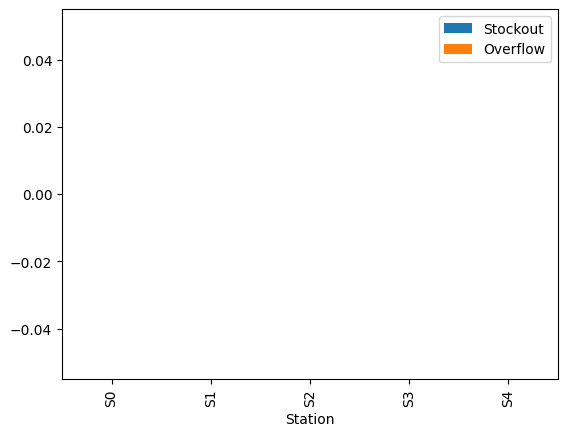

In [12]:
df.set_index("Station")[["Stockout","Overflow"]].plot(kind="bar")

In [ ]:
pip install streamlit pandas plotly

Note: you may need to restart the kernel to use updated packages.


In [16]:
import streamlit as st
import pandas as pd
import random
import matplotlib.pyplot as plt

st.title("🚲 BIXI Digital Twin Dashboard")

# -----------------------------
# SIMULATION SETUP
# -----------------------------
num_stations = 5
capacity = [20]*num_stations
bikes = [random.randint(5,20) for _ in range(num_stations)]

stockout = [0]*num_stations
overflow = [0]*num_stations
pickups = [0]*num_stations
returns = [0]*num_stations

# -----------------------------
# SIMULATION FUNCTION
# -----------------------------
def simulate():
    global bikes
    for i in range(num_stations):
        demand = random.randint(0, 3)
        ret = random.randint(0, 3)

        # pickups
        for _ in range(demand):
            if bikes[i] > 0:
                bikes[i] -= 1
                pickups[i] += 1
            else:
                stockout[i] += 1

        # returns
        for _ in range(ret):
            if bikes[i] < capacity[i]:
                bikes[i] += 1
                returns[i] += 1
            else:
                overflow[i] += 1

# Run simulation multiple steps
for _ in range(10):
    simulate()

# -----------------------------
# DASHBOARD DATA
# -----------------------------
df = pd.DataFrame({
    "Station": [f"S{i}" for i in range(num_stations)],
    "Bikes": bikes,
    "Stockout": stockout,
    "Overflow": overflow,
    "Pickups": pickups,
    "Returns": returns
})

# -----------------------------
# KPI CARDS
# -----------------------------
st.subheader("📊 KPI Summary")

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Stockout", sum(stockout))
col2.metric("Total Overflow", sum(overflow))
col3.metric("Total Pickups", sum(pickups))
col4.metric("Total Returns", sum(returns))

# -----------------------------
# TABLE
# -----------------------------
st.subheader("📋 Station Data")
st.dataframe(df)

# -----------------------------
# CHART
# -----------------------------
st.subheader("📈 KPI Visualization")

fig, ax = plt.subplots()
df.set_index("Station")[["Stockout", "Overflow"]].plot(kind="bar", ax=ax)
st.pyplot(fig)

2026-04-15 11:25:50.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:25:50.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:25:50.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:25:50.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:25:50.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:25:50.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:25:50.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:25:50.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
import requests
import streamlit as st
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, Javascript
from geopy.distance import geodesic
import folium

# ---------- LOAD REAL BIXI DATA ----------
status_url = "https://gbfs.velobixi.com/gbfs/en/station_status.json"
info_url = "https://gbfs.velobixi.com/gbfs/en/station_information.json"

status_data = requests.get(status_url).json()
info_data = requests.get(info_url).json()

status_df = pd.DataFrame(status_data["data"]["stations"])
info_df = pd.DataFrame(info_data["data"]["stations"])

df = pd.merge(status_df, info_df, on="station_id")
df = df.rename(columns={
    "num_bikes_available": "bikes",
    "num_docks_available": "docks"
})

# ---------- WIDGETS ----------
lat_input = widgets.FloatText(value=45.495, description="Lat:")
lon_input = widgets.FloatText(value=-73.578, description="Lon:")

query_input = widgets.Text(
    value="",
    placeholder="Ask: Where can I find a bike? / Where can I return my bike?",
    description="Query:",
    layout=widgets.Layout(width="70%")
)

output = widgets.Output()
ask_button = widgets.Button(description="Ask BIXI Assistant", button_style="primary")
location_button = widgets.Button(description="Use Current Location")

# ---------- HELPERS ----------
def get_best_stations(user_location, condition="bike", min_available=2, top_n=3):
    candidates = []

    for _, row in df.iterrows():
        station_loc = (row["lat"], row["lon"])
        dist = geodesic(user_location, station_loc).meters

        if condition == "bike" and row["bikes"] >= min_available:
            candidates.append((dist, row))
        elif condition == "dock" and row["docks"] >= min_available:
            candidates.append((dist, row))

    candidates.sort(key=lambda x: x[0])
    return candidates[:top_n]

def show_map(user_location, stations, mode="bike"):
    m = folium.Map(location=user_location, zoom_start=15)

    folium.Marker(
        user_location,
        tooltip="You",
        icon=folium.Icon(color="blue", icon="user")
    ).add_to(m)

    for i, (dist, station) in enumerate(stations, start=1):
        color = "green" if i == 1 else "orange"
        popup_text = (
            f"{i}. {station['name']}<br>"
            f"Distance: {int(dist)} m<br>"
            f"{'Bikes' if mode == 'bike' else 'Docks'} available: "
            f"{station['bikes'] if mode == 'bike' else station['docks']}"
        )
        folium.Marker(
            [station["lat"], station["lon"]],
            tooltip=f"{i}. {station['name']}",
            popup=popup_text,
            icon=folium.Icon(color=color)
        ).add_to(m)

    return m

def use_current_location(_):
    display(Javascript("""
    navigator.geolocation.getCurrentPosition(
        (pos) => {
            alert(
                "Current location found.\\n\\n" +
                "Latitude: " + pos.coords.latitude + "\\n" +
                "Longitude: " + pos.coords.longitude + "\\n\\n" +
                "Please copy these values into the Lat/Lon boxes if they do not auto-fill in this notebook environment."
            );
        },
        (err) => {
            alert("Location access failed: " + err.message);
        }
    );
    """))

def handle_query(_):
    with output:
        output.clear_output()

        query = query_input.value.lower().strip()
        user_location = (lat_input.value, lon_input.value)

        # RETURN FIRST so "Where can I return a bike?" does not match the bike branch
        if "return" in query or "dock" in query or "park" in query:
            best = get_best_stations(user_location, condition="dock", min_available=2, top_n=3)

            if not best:
                print("🤖 Sorry, I could not find a nearby station with enough docking space.")
                return

            print("🤖 I found the best nearby stations where you can return your bike:\n")
            for i, (dist, station) in enumerate(best, start=1):
                print(f"{i}. {station['name']}")
                print(f"   Distance: {int(dist)} meters")
                print(f"   Docks available: {station['docks']}\n")

            display(show_map(user_location, best, mode="dock"))

        elif "bike" in query or "find" in query or "ride" in query or "available" in query:
            best = get_best_stations(user_location, condition="bike", min_available=2, top_n=3)

            if not best:
                print("🤖 Sorry, I could not find a nearby station with enough bikes available.")
                return

            print("🤖 I found the best nearby stations where you can get a bike:\n")
            for i, (dist, station) in enumerate(best, start=1):
                print(f"{i}. {station['name']}")
                print(f"   Distance: {int(dist)} meters")
                print(f"   Bikes available: {station['bikes']}\n")

            display(show_map(user_location, best, mode="bike"))

        elif "stockout" in query or "empty" in query or "no bikes" in query:
            stockouts = df[df["bikes"] == 0][["name", "bikes", "docks"]]
            if stockouts.empty:
                print("🤖 There are currently no stockout stations in the live feed.")
            else:
                print("🤖 These stations currently have no bikes:")
                display(stockouts)

        elif "overflow" in query or "full" in query or "no docks" in query:
            fulls = df[df["docks"] == 0][["name", "bikes", "docks"]]
            if fulls.empty:
                print("🤖 There are currently no fully occupied stations in the live feed.")
            else:
                print("🤖 These stations currently have no docking space:")
                display(fulls)

        else:
            print("🤖 Try asking one of these:")
            print("- Where can I find a bike?")
            print("- Where can I return my bike?")
            print("- Which stations are empty?")
            print("- Which stations are full?")

# ---------- EVENTS ----------
ask_button.on_click(handle_query)
location_button.on_click(use_current_location)

# ---------- DISPLAY ----------
display(
    widgets.VBox([
        widgets.HTML("<h3>🤖 BIXI Smart Assistant</h3>"),
        widgets.HTML("<b>Live BIXI data + location-aware recommendations</b>"),
        lat_input,
        lon_input,
        location_button,
        query_input,
        ask_button,
        output
    ])
)
